In [1]:
import sys
import networkx as nx
import numpy as np
import pypsa
from scipy.sparse import spdiags

sys.path.append('./')
from power_system_split import utils, cascade_sim
from matplotlib import pyplot as plt

import pandas as pd
from tqdm import tqdm


# Setup

In [2]:
# Setup paths to solved PyPSA networks and results of this script
path_to_pypsa_network   = './data/European_networks_sclopf/'
save_path =  './results/cascade_results/sclopf/'

# Setup parameters
co2l = 0.5
selected_snapshot_idxs = np.random.randint(0,2920, size=1)

# Load PyPSA network and prepare matrices

In [94]:
# Load PyPSA network
network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+f'sclopf-elec_s_800_ec_lv1.0_Co2L{co2l}-3H.nc')

# The following line is needed to remove the outage lines used for SCLOPF. When not removed, multiple edges 
# are added to the network graph
outage_lines = network.lines[network.lines.index.str[-6:]=='outage'].index
network.mremove('Line', outage_lines)
network.determine_network_topology()

######
#TODO: remove this line if the networks contain timestamp snapshots
network.snapshots = pd.date_range(start='2013', freq='3H', periods=len(network.snapshots))

network.snapshot_weightings.index = pd.date_range(start='2013', freq='3H', periods=len(network.snapshots))

for component in network.all_components:
    pnl = network.pnl(component)
    attrs = network.components[component]["attrs"]

    for k,default in attrs.default[attrs.varying].iteritems():
        pnl[k].index = pd.date_range(start='2013', freq='3H', periods=len(network.snapshots))
######

# Select a particular subnetwork for calculations (if the pypsa network has different ones).
# For our data set, "0" indicates the Continental European AC grid. 
snet_index = 0

# Build graph for subnetwork
G = utils.build_networkx_graph(network, snet_index= snet_index)

# Get line index 
# Line index is a unique number to identify the given edge.
# It is directly extracted from pypsa
indices = nx.get_edge_attributes(G, 'line_index')

# Build incidence matrix and susceptance matrix
I_m = utils.construct_incidencematrix_from_orientation(G,return_np_array = False)
B_d = spdiags(np.array([attribs['weight'] for u,v, attribs in G.edges(data=True)]),
            0,G.number_of_edges(),G.number_of_edges()).asformat('csr')

# Get array of num_parallels and of line limits
num_parallel_list = np.array([attribs['num_parallel'] for u,v, attribs in G.edges(data=True)])
line_limit_list = np.array([attribs['s_nom'] for u,v, attribs in G.edges(data=True)])

# Calculate possible single line failure (using non-bridges)
bridges = list(nx.bridges(nx.Graph(G)))
link_indices = dict(zip(G.edges(), range(G.number_of_edges())))
bridges_indices = [link_indices[link_name] for link_name in bridges]
n_minus_1_failures = list(set(range(len(num_parallel_list))) - set(bridges_indices))

/home/jokruse/anaconda3/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jokruse/anaconda3/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network sclopf-elec_s_800_ec_lv1.0_Co2L0.5-3H.nc has buses, carriers, generators, lines, links, loads, storage_units


# Simulation of N-1 failures

In [95]:
cascade_results = pd.DataFrame(columns=['snapshot','snapshot_idx', 'co2l', 'epsilon',
                                        'init_failure_idx', 'init_failure_name',
                                        'num_parallel_before', 'num_parallel_after',
                                        'n_secondary_failures', 'secondary_failures_indices'])

i=0
for snapshot_idx in selected_snapshot_idxs:
    
    snapshot = network.snapshots[snapshot_idx]
    
    print(snapshot)
    initial_loading = {e: np.sum([network.lines_t.p0.loc[snapshot].loc[index] for index in index_list]) for
                        e, index_list in indices.items()}
    P_0 = utils.get_effective_injections(G, initial_loading)
    
    for init_failure in tqdm(n_minus_1_failures):
        
        initial_failure = [init_failure]
        failing_links, system_split = cascade_sim.simulate_cascade(I_m, B_d, P_0, line_limit_list,
                                                                    num_parallel_list, initial_failure,
                                                                    max_cascade_length=1)
        if len(failing_links)>1:
            cascade_results.loc[i,'snapshot'] = snapshot
            cascade_results.loc[i,'snapshot_idx'] = snapshot_idx
            cascade_results.loc[i,'co2l'] = co2l
            cascade_results.loc[i,'epsilon'] = 0.01
            cascade_results.loc[i,'init_failure_idx'] = init_failure
            cascade_results.loc[i,'init_failure_name'] = utils.transform_cascade_results(G, [init_failure])[0]
            cascade_results.loc[i,'num_parallel_before'] = num_parallel_list[init_failure]
            cascade_results.loc[i,'num_parallel_after'] = cascade_sim.calc_num_parallel_after_failure(num_parallel_list[init_failure])
            cascade_results.loc[i,'n_secondary_failures'] = len(failing_links)-1
            cascade_results.loc[i,'secondary_failures_indices'] = failing_links[1:]
            i+=1

cascade_results

2013-12-07 00:00:00


  2%|▏         | 19/956 [00:00<00:13, 69.96it/s]/home/jokruse/anaconda3/envs/system_split/lib/python3.7/site-packages/scipy/sparse/linalg/dsolve/linsolve.py:206: MatrixRankWarning: Matrix is exactly singular
  warn("Matrix is exactly singular", MatrixRankWarning)
100%|██████████| 956/956 [00:07<00:00, 125.53it/s]


,snapshot,snapshot_idx,co2l,epsilon,init_failure_idx,init_failure_name,num_parallel_before,num_parallel_after,n_secondary_failures,secondary_failures_indices
0,2013-12-07 00:00:00,2720,0.5,0.01,32,"(DE0 3, DE0 71)",1.00554,0.00554,1,[32]
1,2013-12-07 00:00:00,2720,0.5,0.01,121,"(BE0 4, NL0 26)",2.00000,1.00000,1,[121]
2,2013-12-07 00:00:00,2720,0.5,0.01,149,"(LU0 0, DE0 118)",1.00554,0.00554,1,[149]
3,2013-12-07 00:00:00,2720,0.5,0.01,150,"(BE0 7, NL0 15)",2.00000,1.00000,1,[150]
4,2013-12-07 00:00:00,2720,0.5,0.01,285,"(PL0 3, PL0 34)",0.33518,0,2,"[986, 987]"
5,2013-12-07 00:00:00,2720,0.5,0.01,370,"(DE0 84, DE0 67)",2.00000,1.00000,1,[370]
6,2013-12-07 00:00:00,2720,0.5,0.01,377,"(DE0 126, DE0 59)",0.67036,0.33518,1,[377]
7,2013-12-07 00:00:00,2720,0.5,0.01,383,"(DE0 50, DE0 51)",2.00000,1.00000,1,[383]
8,2013-12-07 00:00:00,2720,0.5,0.01,402,"(DE0 21, DE0 79)",2.00000,1.00000,1,[402]
9,2013-12-07 00:00:00,2720,0.5,0.01,427,"(DE0 124, DE0 62)",2.00000,1.00000,1,[427]


# Evaluation of one initial failure event

In [121]:
# Choose result 
result_idx = 4

# Pre-failure flow
snapshot = cascade_results.iloc[result_idx].snapshot
initial_loading = {e: np.sum([network.lines_t.p0.loc[snapshot].loc[index] for index in index_list]) for
                   e, index_list in indices.items()}
P_0 = utils.get_effective_injections(G, initial_loading)
pre_flows = cascade_sim.solve_lpf(P_0, B_d, I_m)

# Post-fault flows
B_d_post = B_d.copy()
num_parallel_list_post = num_parallel_list.copy()
line_limit_list_post = line_limit_list.copy()
cascade_sim.remove_line_from_Bd(B_d_post, num_parallel_list_post, line_limit_list_post,
                                cascade_results.iloc[result_idx].init_failure_idx)
post_flows = cascade_sim.solve_lpf(P_0, B_d_post, I_m)

In [122]:
# Load PyPSA network including outage lines
network_w_outages = pypsa.Network()
network_w_outages.import_from_netcdf(path_to_pypsa_network+f'sclopf-elec_s_800_ec_lv1.0_Co2L{co2l}-3H.nc')

init_fail_in_bus, init_fail_out_bus = utils.transform_cascade_results(G, [cascade_results.iloc[result_idx].init_failure_idx])[0]
init_line_info = network_w_outages.lines[(network_w_outages.lines.bus1==init_fail_in_bus)&(network_w_outages.lines.bus0==init_fail_out_bus)]
if init_line_info.empty:
    init_line_info = network_w_outages.lines[(network_w_outages.lines.bus1==init_fail_out_bus)&(network_w_outages.lines.bus0==init_fail_in_bus)]
    
init_line_info

/home/jokruse/anaconda3/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jokruse/anaconda3/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network sclopf-elec_s_800_ec_lv1.0_Co2L0.5-3H.nc has buses, carriers, generators, lines, links, loads, storage_units


,bus0,bus1,num_parallel,length,type,s_max_pu,s_nom,capital_cost,x,r,...,s_nom_min,s_nom_max,terrain_factor,v_ang_min,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu
name,,,,,,,,,,,,,,,,,,,,,
1164,PL0 3,PL0 34,0.33518,148.151904,Al/St 240/40 4-bundle 380.0,0.7,569.170127,5644.384416,108.733703,13.260208,...,0.0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
1164_outage,PL0 3,PL0 34,0.00100,148.151904,Al/St 240/40 4-bundle 380.0,0.7,1.698103,5644.384416,36445.368460,4444.557129,...,0.0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0


In [123]:
# Compare flow on init failing line (between cascade results and PyPSA information)

print('Pre-Flow in simulation:', pre_flows[cascade_results.init_failure_idx[result_idx]])
print('Pre-Flow in PyPSA', network_w_outages.lines_t.p0.loc[cascade_results.snapshot_idx[result_idx], init_line_info.index[0]])

print('Post-Flow in simulation:', post_flows[cascade_results.init_failure_idx[result_idx]])
print('Post-Flow in PyPSA', network_w_outages.lines_t.p0.loc[cascade_results.snapshot_idx[result_idx], init_line_info.index[1]])

Pre-Flow in simulation: -257.0356753779762
Pre-Flow in PyPSA -257.03567479246425
Post-Flow in simulation: 0.0
Post-Flow in PyPSA -0.766858500231719


In [126]:
line_limit_list_post[986]

569.170127480897

In [124]:
post_flows[986]

-606.3383957353178

In [120]:
83.10136981253731 / 0.4578587063033845

181.5000319279132

In [104]:
1919.1708532907212 / 959.5855615103674

1.9999997189098875

In [100]:
2377.3393385539534 / 1188.6696692769767

2.0

In [99]:
network.lines.x_pu_eff.loc['666']

7.310151253645897e-05

In [85]:
network.lines.x_pu_eff.loc['658'] #network.lines.x_pu_eff.loc['658']

2.5690628015975534e-05

In [56]:
8.944664071597593 / 0.9763975306630307

9.16088354455756

In [70]:
35.78650473249041 / 3.906446680720533

9.160883958587574

In [76]:
14.19276792732104/1.1112684172772327


12.77168297655337

In [41]:
network.generators_t.p_set = network.generators_t.p
network.lpf(snapshots=snapshot)

INFO:pypsa.pf:Performing linear load-flow on AC sub-network SubNetwork 0 for snapshot(s) DatetimeIndex(['2013-12-07'], dtype='datetime64[ns]', freq=None)
INFO:pypsa.pf:Performing linear load-flow on AC sub-network SubNetwork 1 for snapshot(s) DatetimeIndex(['2013-12-07'], dtype='datetime64[ns]', freq=None)
INFO:pypsa.pf:Performing linear load-flow on AC sub-network SubNetwork 2 for snapshot(s) DatetimeIndex(['2013-12-07'], dtype='datetime64[ns]', freq=None)
INFO:pypsa.pf:Performing linear load-flow on AC sub-network SubNetwork 3 for snapshot(s) DatetimeIndex(['2013-12-07'], dtype='datetime64[ns]', freq=None)
INFO:pypsa.pf:Performing linear load-flow on AC sub-network SubNetwork 4 for snapshot(s) DatetimeIndex(['2013-12-07'], dtype='datetime64[ns]', freq=None)
INFO:pypsa.pf:Performing linear load-flow on AC sub-network SubNetwork 5 for snapshot(s) DatetimeIndex(['2013-12-07'], dtype='datetime64[ns]', freq=None)


attribute,carrier,slack_bus
name,,


In [112]:
network_w_outages.sub_networks.obj[0].calculate_BODF()

AttributeError: 'DataFrame' object has no attribute 'obj'

In [111]:
network.sub_networks.obj[0].BODF

array([[-1.00000000e+00,  1.70534601e-01,  3.64714297e-01, ...,
         1.65839347e-04,  4.42657432e-04, -6.00442488e-04],
       [ 2.09277109e-01, -1.00000000e+00,  2.73701209e-01, ...,
        -6.05869504e-04, -1.62072654e-03,  2.20483712e-03],
       [ 5.25397164e-01,  3.21293866e-01, -1.00000000e+00, ...,
         2.74021742e-04,  7.32075299e-04, -9.94212466e-04],
       ...,
       [ 1.29348511e-04, -3.85073586e-04,  1.48362431e-04, ...,
        -1.00000000e+00, -1.16401694e-01,  2.86500950e-02],
       [ 9.09231676e-04, -2.71273471e-03,  1.04382481e-03, ...,
        -3.06543594e-01, -1.00000000e+00, -3.59511462e-01],
       [-7.40740667e-04,  2.21647108e-03, -8.51410578e-04, ...,
         4.53155219e-02, -2.15923900e-01, -1.00000000e+00]])

In [90]:
network.lpf_contingency(snapshots=snapshot, branch_outages=['1162'])

INFO:pypsa.pf:Performing linear load-flow on AC sub-network SubNetwork 0 for snapshot(s) DatetimeIndex(['2013-12-07'], dtype='datetime64[ns]', freq=None)
INFO:pypsa.pf:Performing linear load-flow on AC sub-network SubNetwork 1 for snapshot(s) DatetimeIndex(['2013-12-07'], dtype='datetime64[ns]', freq=None)
INFO:pypsa.pf:Performing linear load-flow on AC sub-network SubNetwork 2 for snapshot(s) DatetimeIndex(['2013-12-07'], dtype='datetime64[ns]', freq=None)
INFO:pypsa.pf:Performing linear load-flow on AC sub-network SubNetwork 3 for snapshot(s) DatetimeIndex(['2013-12-07'], dtype='datetime64[ns]', freq=None)
INFO:pypsa.pf:Performing linear load-flow on AC sub-network SubNetwork 4 for snapshot(s) DatetimeIndex(['2013-12-07'], dtype='datetime64[ns]', freq=None)
INFO:pypsa.pf:Performing linear load-flow on AC sub-network SubNetwork 5 for snapshot(s) DatetimeIndex(['2013-12-07'], dtype='datetime64[ns]', freq=None)
/home/jokruse/anaconda3/envs/system_split/lib/python3.7/site-packages/scipy/

base (Line, 1162)
     name                  
Line 1     NaN          NaN
     2     NaN          NaN
     3     NaN          NaN
     4     NaN          NaN
     5     NaN          NaN
...        ...          ...
     1288  NaN          NaN
     1289  NaN          NaN
     1290  NaN          NaN
     1291  NaN          NaN
     1292  NaN          NaN

[1292 rows x 2 columns]

# Visualization of failure event

(<matplotlib.collections.PatchCollection at 0x7f71b832be50>,
 <matplotlib.collections.LineCollection at 0x7f71af9dd690>)

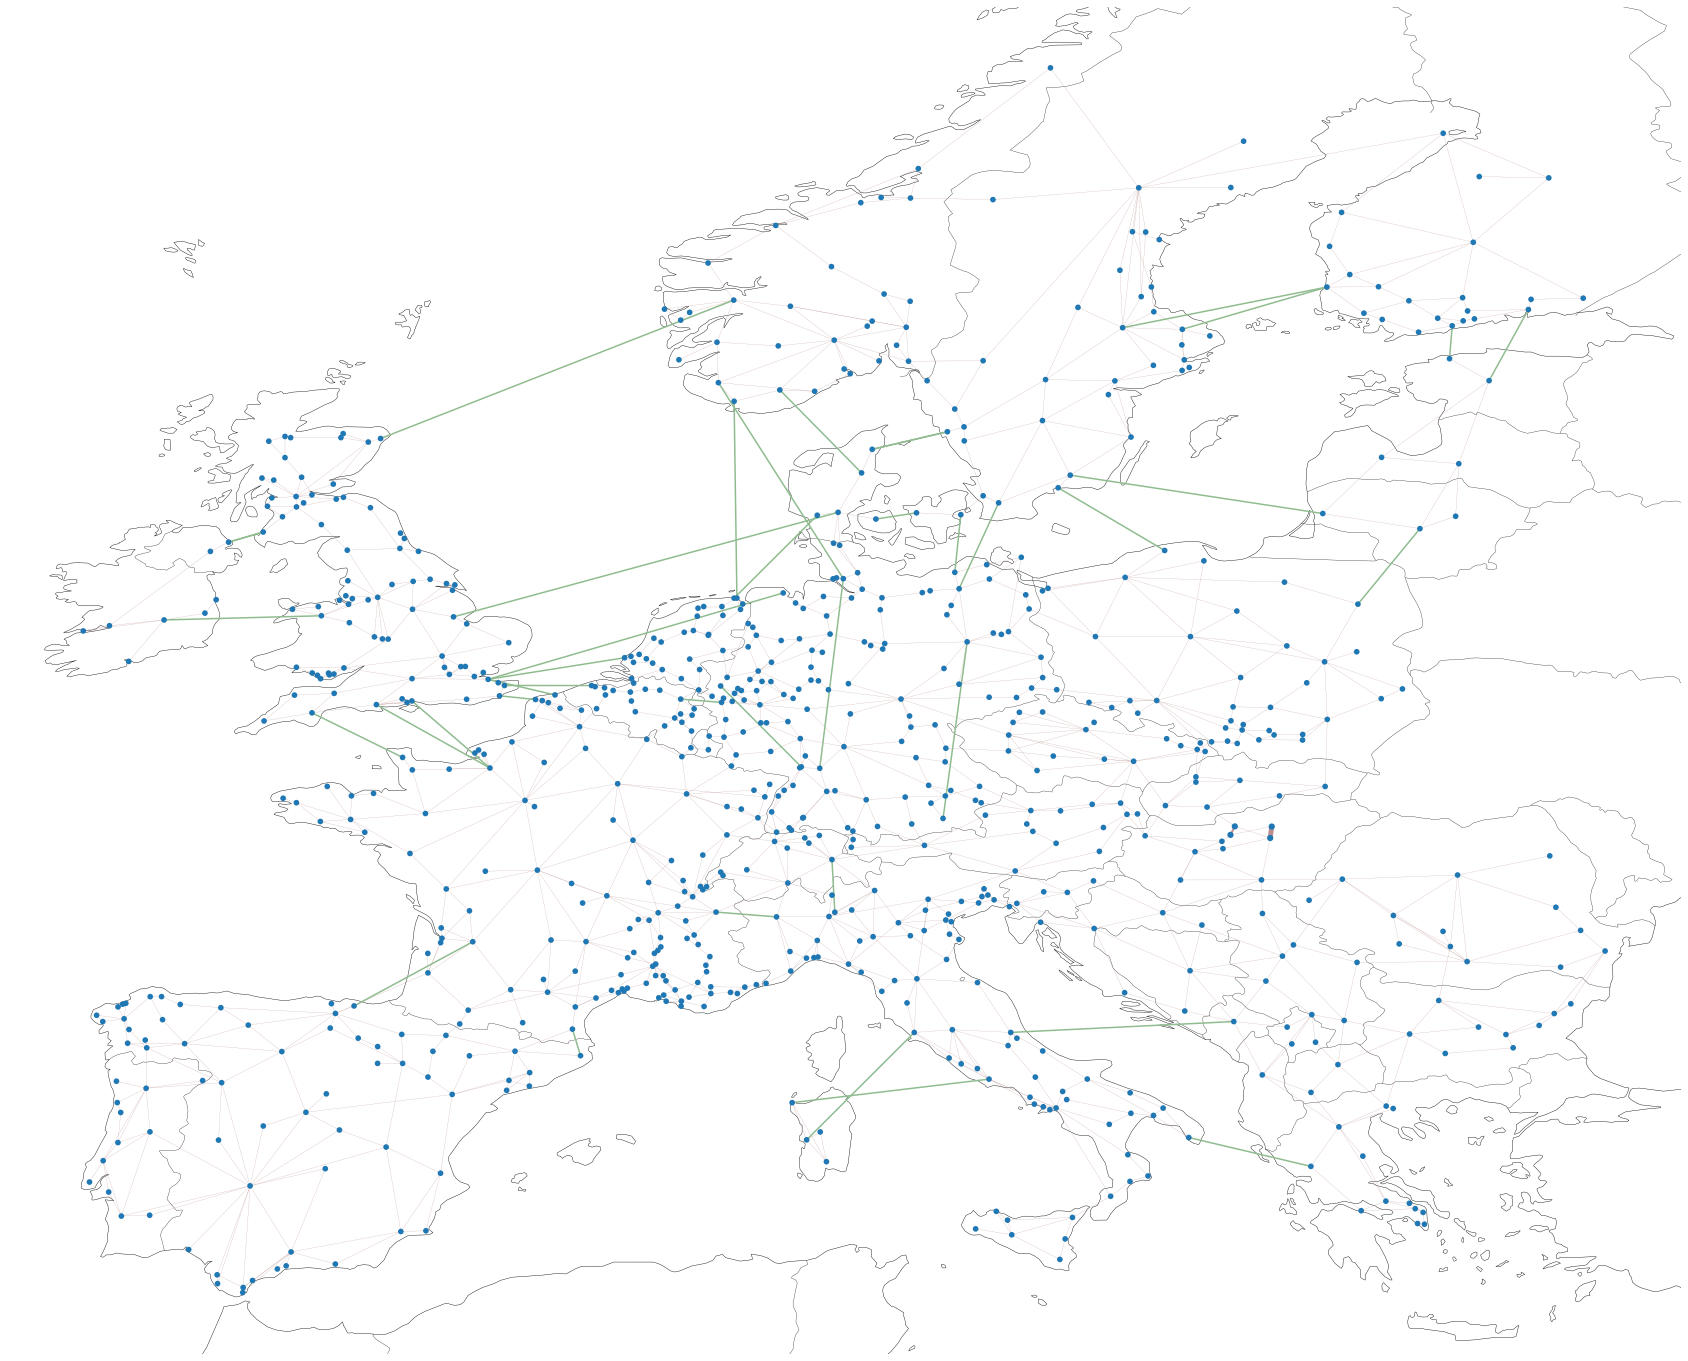

In [114]:
# Plot map of subgraphs and failing links

plt.figure(figsize=(30,30))
lws = np.ones(network.lines.shape[0])*0.2
bs = np.ones(network.buses.shape[0])*0.005
bc = np.ones(network.buses.shape[0])

failing_lines_names = utils.transform_cascade_results(G, cascade_results.secondary_failures_indices[result_idx])
for e in failing_lines_names:
    lws[((network.lines.bus0==e[0])&(network.lines.bus1==e[1]))|((network.lines.bus0==e[1])&(network.lines.bus1==e[0]))]=2
    bs[network.buses.index==e[0]] =0.006
    bs[network.buses.index==e[1]] =0.006
    
e = cascade_results.init_failure_name[result_idx]
lws[((network.lines.bus0==e[0])&(network.lines.bus1==e[1]))|((network.lines.bus0==e[1])&(network.lines.bus1==e[0]))]=5
bs[network.buses.index==e[0]] =0.006
bs[network.buses.index==e[1]] =0.006
    

network.plot(line_widths=lws, bus_sizes=bs, jitter=0., bus_colors=bc, bus_cmap='tab20')